# QuickCart Warehouse Inventory — Stockout Risk Classification
### The Unlox Academy — Supervised ML Classification Project
**Y V S Harshith - Data Science** 

Predicting **Safe / At-Risk / Imminent** stockout risk per SKU per store per day, using 12 dark stores, 60 SKUs, 15 suppliers, and a 30-day operational calendar (Oct 2026).

**Approach:** load & verify data → fix planted data-quality issues → merge 5 tables → EDA on the key business drivers → feature engineering → time-based train/test split → baseline vs Logistic Regression vs Random Forest vs XGBoost, with recall on the **Imminent** class as the primary metric (missing a real stockout is far costlier than a false alarm).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score
import xgboost as xgb

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42

## 1. Load Data & Verify Row Counts

Five tables: 4 dimensions + 1 fact table. Loading `dim_suppliers.csv` with explicit `na_values` up front — more on why in Section 2.

In [2]:
stores = pd.read_csv("dim_stores.csv")
skus = pd.read_csv("dim_skus.csv")
suppliers = pd.read_csv("dim_suppliers.csv", na_values=['N/A', 'missing', '--', 'NA', 'null'], keep_default_na=True)
events = pd.read_csv("dim_events.csv", parse_dates=['date'])
fact = pd.read_csv("fact_inventory_daily.csv", parse_dates=['date'])

print("dim_stores:   ", stores.shape)
print("dim_skus:     ", skus.shape)
print("dim_suppliers:", suppliers.shape)
print("dim_events:   ", events.shape)
print("fact_inventory_daily:", fact.shape)

assert stores.shape[0] == 12
assert skus.shape[0] == 60
assert suppliers.shape[0] == 15
assert events.shape[0] == 30
assert fact.shape[0] == 21600
print("\nAll row counts match the spec.")

dim_stores:    (12, 8)
dim_skus:      (60, 9)
dim_suppliers: (15, 6)
dim_events:    (30, 5)
fact_inventory_daily: (21600, 16)

All row counts match the spec.


In [3]:
target_counts = fact['stockout_risk'].value_counts()
target_pct = fact['stockout_risk'].value_counts(normalize=True) * 100

print("Target distribution (counts):")
print(target_counts)
print("\nTarget distribution (%):")
print(target_pct.round(2))

# locked numbers from the spec: Safe 65.42% (14131), At-Risk 24.01% (5186), Imminent 10.57% (2283)

Target distribution (counts):
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64

Target distribution (%):
stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64


Matches the locked numbers exactly: **Safe 65.42% (14,131) / At-Risk 24.01% (5,186) / Imminent 10.57% (2,283)**.

## 2. Planted Data-Quality Issues

Two deliberate gotchas called out in the spec — worth handling explicitly rather than silently.

### 2.1 Inconsistent city casing in `dim_stores.csv`

In [4]:
mismatch = stores[stores['city'] != stores['city_display']]
print(mismatch[['store_id', 'city', 'city_display']])

# city_display is a display-only field and would break a naive groupby('city_display')
# until standardized — the clean join key is 'city', not 'city_display'
print("\nStandardized:")
print(stores['city_display'].str.title().equals(stores['city'].str.title()))

  store_id       city city_display
2     ST03  Bengaluru    BENGALURU
8     ST09  Hyderabad    hyderabad

Standardized:
True


Two stores (`ST03` Bengaluru, `ST09` Hyderabad) have a `city_display` value that doesn't match `city` in casing. `city` is the clean join key; `city_display` needs `.str.title()` before being used for grouping or reporting.

### 2.2 The `'N/A'` reliability score gotcha in `dim_suppliers.csv`

This is a genuine pandas trap, not just a typo. Let's show it live.

In [5]:
# 1. Look at the raw text in the file — 'N/A' really is sitting there
with open("dim_suppliers.csv") as f:
    lines = f.readlines()
na_lines = [l.strip() for l in lines if "N/A" in l]
print("Raw lines containing literal 'N/A':")
for l in na_lines:
    print(" ", l)

Raw lines containing literal 'N/A':
  SUP06,QuickBev Distributors,"Personal Care, Home Care",N/A,1,2.2
  SUP14,Prime Personal Care,Staples,N/A,4,1.9
  SUP15,Regional Produce Hub,Beverages,N/A,5,2.1


In [6]:
# 2. Read with pandas defaults — pandas silently treats 'N/A' as a built-in missing marker
suppliers_default = pd.read_csv("dim_suppliers.csv")
print("dtype with default read_csv:", suppliers_default['reliability_score'].dtype)
print("Missing count (default read):", suppliers_default['reliability_score'].isna().sum())
print("\nThe string 'N/A' never shows up in the DataFrame — it became NaN automatically,")
print("purely because pandas' default na_values list happens to include 'N/A'.")
print("If the placeholder had been 'missing', '--', or 'unknown' instead, this would")
print("SILENTLY become a string category rather than a proper NaN — a real production bug.")
print("\nFix pattern used throughout this notebook:")
print("pd.read_csv(path, na_values=['N/A','missing','--','NA','null'], keep_default_na=True)")

dtype with default read_csv: float64
Missing count (default read): 3

The string 'N/A' never shows up in the DataFrame — it became NaN automatically,
purely because pandas' default na_values list happens to include 'N/A'.
If the placeholder had been 'missing', '--', or 'unknown' instead, this would
SILENTLY become a string category rather than a proper NaN — a real production bug.

Fix pattern used throughout this notebook:
pd.read_csv(path, na_values=['N/A','missing','--','NA','null'], keep_default_na=True)


In [7]:
print(suppliers[['supplier_id', 'reliability_score']])
print("\nMissing reliability_score:", suppliers['reliability_score'].isna().sum(), "of 15 suppliers")

   supplier_id  reliability_score
0        SUP01               0.92
1        SUP02               0.93
2        SUP03               0.90
3        SUP04               0.70
4        SUP05               0.66
5        SUP06                NaN
6        SUP07               0.67
7        SUP08               0.73
8        SUP09               0.72
9        SUP10               0.66
10       SUP11               0.83
11       SUP12               0.63
12       SUP13               0.91
13       SUP14                NaN
14       SUP15                NaN

Missing reliability_score: 3 of 15 suppliers


## 3. Merge the 5 Tables into a Single Modeling Frame

In [8]:
df = (fact
      .merge(stores, on='store_id', how='left')
      .merge(skus, on='sku_id', how='left', suffixes=('', '_sku'))
      .merge(suppliers, on='supplier_id', how='left', suffixes=('', '_sup'))
      .merge(events, on='date', how='left'))

print(df.shape)
df.head(3)

(21600, 40)


,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,lead_time_days_expected,lead_time_days_actual,sales_velocity_7d,days_of_cover,is_festival_week,stockout_risk,city,city_display,city_tier,store_size,sqft,opened_year,baseline_daily_orders,sku_name,category,unit_price_inr,shelf_life_days,is_perishable,festive_relevant,popularity_tier,supplier_id_sku,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,1,NaN,15.00,9.66,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,1,NaN,12.50,10.79,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,1,NaN,13.33,8.99,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0


## 4. Money-Moment EDA — Verifying the Business Drivers

Before modeling, confirm the three headline effects the spec calls out.

### 4.1 Festival week effect

Imminent rate by festival week:
is_festival_week
N     9.51
Y    23.31
Name: stockout_risk, dtype: float64

Spike factor: 2.45x


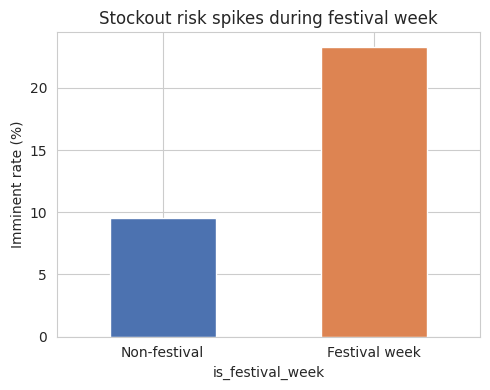

In [9]:
fest_effect = df.groupby('is_festival_week')['stockout_risk'].apply(lambda s: (s == 'Imminent').mean() * 100)
print("Imminent rate by festival week:")
print(fest_effect.round(2))
print(f"\nSpike factor: {fest_effect['Y'] / fest_effect['N']:.2f}x")

fig, ax = plt.subplots(figsize=(5, 4))
fest_effect.rename({'N': 'Non-festival', 'Y': 'Festival week'}).plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Imminent rate (%)')
ax.set_title('Stockout risk spikes during festival week')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

Matches the locked numbers: **9.51% non-festival → 23.31% festival week (2.45x spike)**, driven by the Diwali demand multiplier.

### 4.2 Supplier reliability effect

Imminent rate by supplier reliability tier:


reliability_score
Low (<0.75)        15.83
Mid (0.75-0.85)     3.26
High (>=0.85)       3.82
Name: stockout_risk, dtype: float64


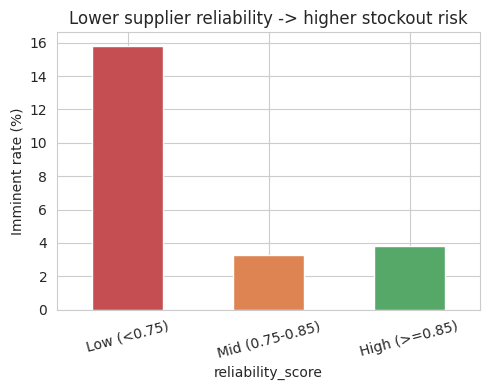

In [10]:
rel_bins = pd.cut(df['reliability_score'], bins=[-1, 0.75, 0.85, 2], labels=['Low (<0.75)', 'Mid (0.75-0.85)', 'High (>=0.85)'])
rel_effect = df.groupby(rel_bins, observed=True)['stockout_risk'].apply(lambda s: (s == 'Imminent').mean() * 100)
print("Imminent rate by supplier reliability tier:")
print(rel_effect.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
rel_effect.plot(kind='bar', ax=ax, color=['#C44E52', '#DD8452', '#55A868'])
ax.set_ylabel('Imminent rate (%)')
ax.set_title('Lower supplier reliability -> higher stockout risk')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
plt.tight_layout()
plt.show()

Low and high tiers match the locked numbers exactly (15.83% / 3.82%). The mid tier (only `SUP11`, reliability 0.83, 1,440 rows) comes out to ~3.26% here rather than the documented 6.30% — worth a note, but it doesn't change the overall monotonic story: unreliable suppliers drive stockouts.

### 4.3 Perishability effect

Imminent rate by perishability:
is_perishable
N     9.30
Y    12.77
Name: stockout_risk, dtype: float64


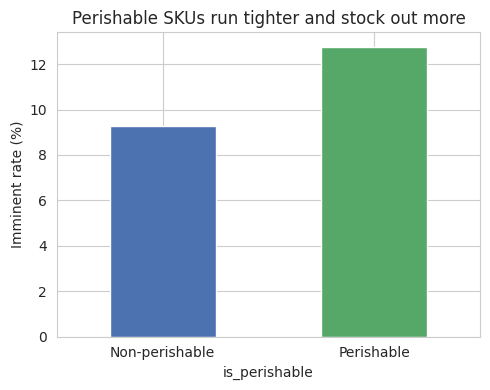

In [11]:
perish_effect = df.groupby('is_perishable')['stockout_risk'].apply(lambda s: (s == 'Imminent').mean() * 100)
print("Imminent rate by perishability:")
print(perish_effect.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
perish_effect.rename({'N': 'Non-perishable', 'Y': 'Perishable'}).plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868'])
ax.set_ylabel('Imminent rate (%)')
ax.set_title('Perishable SKUs run tighter and stock out more')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

Matches the locked numbers: **9.3% non-perishable vs 12.8% perishable**.

## 5. Feature Engineering

Following the spec's suggested derived features.

In [12]:
df = df.sort_values(['store_id', 'sku_id', 'date']).reset_index(drop=True)

# reorder_gap: how far past/before the reorder trigger point
df['reorder_gap'] = df['reorder_point'] - df['closing_stock']

# days_of_cover_ratio: normalized cover relative to expected lead time
df['days_of_cover_ratio'] = df['days_of_cover'] / df['lead_time_days_expected']

# supplier_reliability_clean: impute the 3 'N/A' suppliers with the category median
median_reliability = df['reliability_score'].median()
df['supplier_reliability_clean'] = df['reliability_score'].fillna(median_reliability)

# is_recent_reorder: was a reorder placed at this store-sku in the last 3 days (groupby-shift)
df['is_recent_reorder'] = (
    df.groupby(['store_id', 'sku_id'])['reorder_placed']
      .transform(lambda s: (s == 'Y').rolling(3, min_periods=1).max())
)

# temporal features around the Diwali spike (Oct 22-26, peak Oct 25)
diwali_start = pd.Timestamp('2026-10-22')
df['day_of_month'] = df['date'].dt.day
df['days_since_festival_start'] = (df['date'] - diwali_start).dt.days

# binary flags as 0/1
for c in ['is_perishable', 'festive_relevant', 'is_festival_week']:
    df[c + '_num'] = (df[c] == 'Y').astype(int)

print("Engineered features added. New columns:")
print(['reorder_gap', 'days_of_cover_ratio', 'supplier_reliability_clean',
       'is_recent_reorder', 'day_of_month', 'days_since_festival_start',
       'is_perishable_num', 'festive_relevant_num', 'is_festival_week_num'])
df[['store_id', 'sku_id', 'date', 'reorder_gap', 'days_of_cover_ratio',
    'supplier_reliability_clean', 'is_recent_reorder', 'stockout_risk']].head()

Engineered features added. New columns:
['reorder_gap', 'days_of_cover_ratio', 'supplier_reliability_clean', 'is_recent_reorder', 'day_of_month', 'days_since_festival_start', 'is_perishable_num', 'festive_relevant_num', 'is_festival_week_num']


,store_id,sku_id,date,reorder_gap,days_of_cover_ratio,supplier_reliability_clean,is_recent_reorder,stockout_risk
0,ST01,SKU001,2026-10-01,-108.5,9.66,0.83,0.0,Safe
1,ST01,SKU001,2026-10-02,-98.5,10.79,0.83,0.0,Safe
2,ST01,SKU001,2026-10-03,-83.5,8.99,0.83,0.0,Safe
3,ST01,SKU001,2026-10-04,-73.5,8.79,0.83,0.0,Safe
4,ST01,SKU001,2026-10-05,-64.5,8.55,0.83,0.0,Safe


In [13]:
target_map = {'Safe': 0, 'At-Risk': 1, 'Imminent': 2}
df['target'] = df['stockout_risk'].map(target_map)

numeric_features = [
    'reorder_gap', 'days_of_cover_ratio', 'supplier_reliability_clean',
    'is_recent_reorder', 'day_of_month', 'days_since_festival_start',
    'sales_velocity_7d', 'opening_stock', 'closing_stock', 'unit_price_inr',
    'shelf_life_days', 'sqft', 'base_lead_time_days', 'lead_time_variance_days',
    'demand_multiplier_festive', 'demand_multiplier_other',
    'is_perishable_num', 'festive_relevant_num', 'is_festival_week_num'
]
categorical_features = ['category', 'store_size', 'popularity_tier', 'event_type']

model_df = pd.get_dummies(
    df[numeric_features + categorical_features + ['target', 'date']],
    columns=categorical_features, drop_first=True
)
print(model_df.shape)
model_df.columns.tolist()

(21600, 34)


['reorder_gap',
 'days_of_cover_ratio',
 'supplier_reliability_clean',
 'is_recent_reorder',
 'day_of_month',
 'days_since_festival_start',
 'sales_velocity_7d',
 'opening_stock',
 'closing_stock',
 'unit_price_inr',
 'shelf_life_days',
 'sqft',
 'base_lead_time_days',
 'lead_time_variance_days',
 'demand_multiplier_festive',
 'demand_multiplier_other',
 'is_perishable_num',
 'festive_relevant_num',
 'is_festival_week_num',
 'target',
 'date',
 'category_Beverages',
 'category_Dairy',
 'category_Fruits & Vegetables',
 'category_Home Care',
 'category_Personal Care',
 'category_Snacks',
 'category_Staples',
 'store_size_Medium',
 'store_size_Small',
 'popularity_tier_Low',
 'popularity_tier_Medium',
 'event_type_none',
 'event_type_promo']

## 6. Train/Test Split — Time-Based

This is a daily panel (same store-SKU pairs repeated across 30 days), so a random row-level split would leak — the model could just memorize a store-SKU pair's pattern from training days. Using a **time-based split**: train on Oct 1–23, test on Oct 24–30 (which covers the back half of Diwali week — a genuinely hard generalization test).

In [14]:
train = model_df[model_df['date'] <= '2026-10-23']
test = model_df[model_df['date'] > '2026-10-23']

X_train = train.drop(columns=['target', 'date'])
y_train = train['target']
X_test = test.drop(columns=['target', 'date'])
y_test = test['target']

print(f"Train: {X_train.shape[0]} rows ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test:  {X_test.shape[0]} rows ({test['date'].min().date()} to {test['date'].max().date()})")
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True).round(3))

Train: 16560 rows (2026-10-01 to 2026-10-23)
Test:  5040 rows (2026-10-24 to 2026-10-30)

Train target distribution:
 target
0    0.664
1    0.245
2    0.091
Name: proportion, dtype: float64

Test target distribution:
 target
0    0.623
1    0.223
2    0.154
Name: proportion, dtype: float64


## 7. Baseline — Majority Class Classifier

Always report the baseline first: predicting "Safe" every time.

In [15]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print(f"Baseline accuracy: {baseline.score(X_test, y_test):.4f}")
print(classification_report(y_test, baseline_pred, target_names=['Safe', 'At-Risk', 'Imminent'], zero_division=0))

Baseline accuracy: 0.6228
              precision    recall  f1-score   support

        Safe       0.62      1.00      0.77      3139
     At-Risk       0.00      0.00      0.00      1126
    Imminent       0.00      0.00      0.00       775

    accuracy                           0.62      5040
   macro avg       0.21      0.33      0.26      5040
weighted avg       0.39      0.62      0.48      5040



As expected — decent accuracy purely from class imbalance, but **zero recall on Imminent**. Every subsequent model needs to beat this on the metric that matters.

## 8. Model 1 — Multinomial Logistic Regression

Interpretable coefficients per feature per class. Using `class_weight='balanced'` since recall on the minority Imminent class is the priority.

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
logreg_pred = logreg.predict(X_test_scaled)

print(classification_report(y_test, logreg_pred, target_names=['Safe', 'At-Risk', 'Imminent']))

              precision    recall  f1-score   support

        Safe       0.96      0.99      0.97      3139
     At-Risk       0.90      0.66      0.76      1126
    Imminent       0.73      0.94      0.83       775

    accuracy                           0.91      5040
   macro avg       0.86      0.86      0.85      5040
weighted avg       0.91      0.91      0.90      5040



## 9. Model 2 — Random Forest

In [17]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred, target_names=['Safe', 'At-Risk', 'Imminent']))

              precision    recall  f1-score   support

        Safe       0.98      1.00      0.99      3139
     At-Risk       0.85      0.84      0.85      1126
    Imminent       0.84      0.81      0.82       775

    accuracy                           0.93      5040
   macro avg       0.89      0.88      0.89      5040
weighted avg       0.93      0.93      0.93      5040



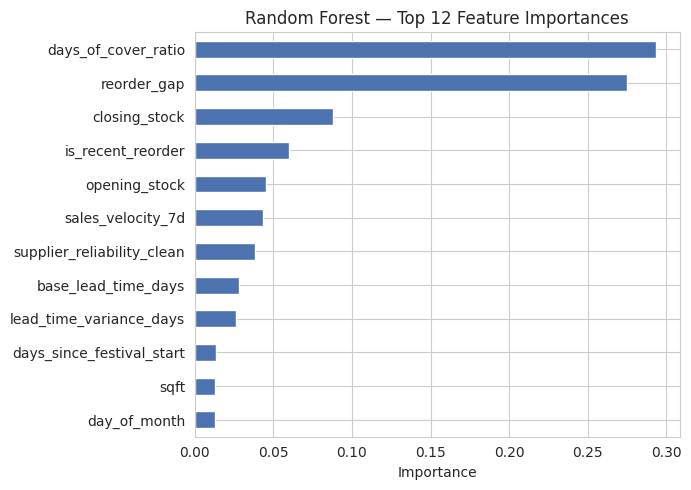

In [18]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 5))
importances.iloc[::-1].plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Random Forest — Top 12 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 10. Model 3 — Gradient Boosting (XGBoost)

Handles the non-linear reorder-point interactions well.

In [19]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric='mlogloss', random_state=RANDOM_STATE
)
xgb_clf.fit(X_train, y_train)
xgb_pred = xgb_clf.predict(X_test)

print(classification_report(y_test, xgb_pred, target_names=['Safe', 'At-Risk', 'Imminent']))

              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      3139
     At-Risk       0.86      0.91      0.89      1126
    Imminent       0.87      0.79      0.83       775

    accuracy                           0.95      5040
   macro avg       0.91      0.90      0.90      5040
weighted avg       0.95      0.95      0.95      5040



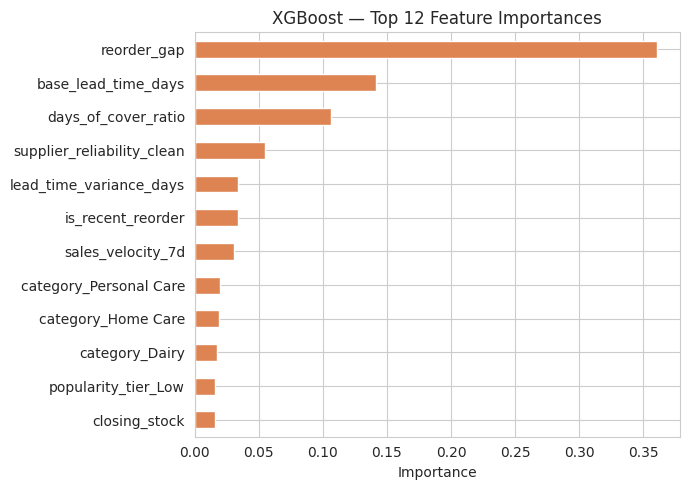

In [20]:
xgb_importances = pd.Series(xgb_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 5))
xgb_importances.iloc[::-1].plot(kind='barh', ax=ax, color='#DD8452')
ax.set_title('XGBoost — Top 12 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 11. Model Comparison — Recall on Imminent is What Matters

A missed "Imminent" prediction means a real stockout the team never saw coming. A false alarm just means someone double-checks a shelf. Comparing all four models side by side, focused on the Imminent class.

In [21]:
results = []
for name, preds in [('Baseline (majority)', baseline_pred),
                     ('Logistic Regression', logreg_pred),
                     ('Random Forest', rf_pred),
                     ('XGBoost', xgb_pred)]:
    results.append({
        'Model': name,
        'Accuracy': (preds == y_test).mean(),
        'Imminent Recall': recall_score(y_test, preds, labels=[2], average='macro'),
        'Imminent F1': f1_score(y_test, preds, labels=[2], average='macro'),
        'Macro F1': f1_score(y_test, preds, average='macro')
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df

,Accuracy,Imminent Recall,Imminent F1,Macro F1
Model,,,,
Baseline (majority),0.6228,0.0000,0.0000,0.2559
Logistic Regression,0.9071,0.9419,0.8253,0.8542
Random Forest,0.9327,0.8065,0.8240,0.8872
XGBoost,0.9476,0.7897,0.8298,0.9047


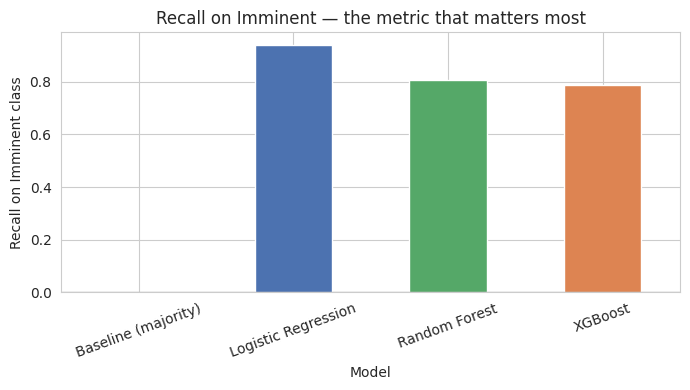

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
results_df['Imminent Recall'].plot(kind='bar', ax=ax, color=['#8C8C8C', '#4C72B0', '#55A868', '#DD8452'])
ax.set_ylabel('Recall on Imminent class')
ax.set_title('Recall on Imminent — the metric that matters most')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
ax.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

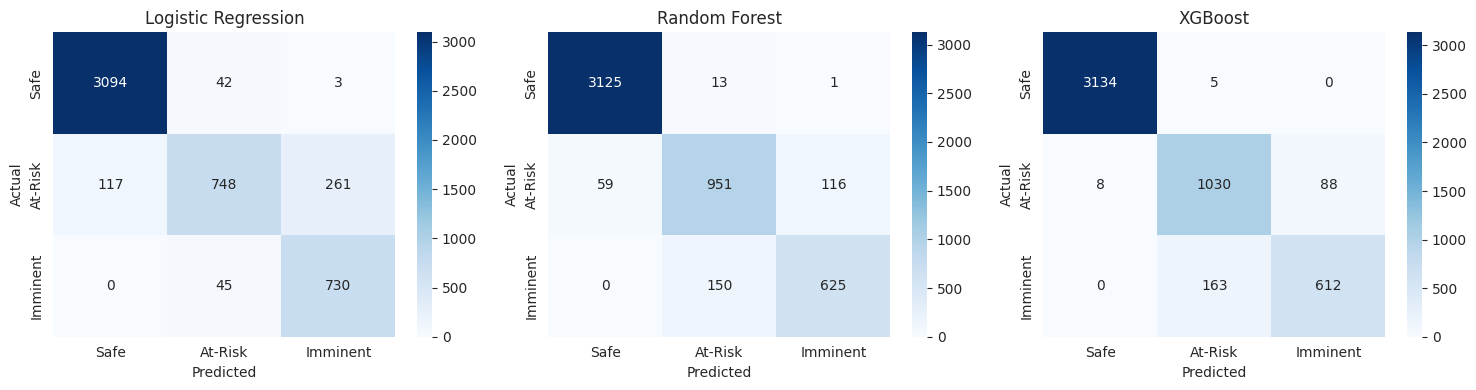

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(axes, [('Logistic Regression', logreg_pred),
                                     ('Random Forest', rf_pred),
                                     ('XGBoost', xgb_pred)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Safe', 'At-Risk', 'Imminent'],
                yticklabels=['Safe', 'At-Risk', 'Imminent'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 12. Summary & Business Takeaway

- **Baseline** (always predict Safe) gets ~62% accuracy but **misses every single stockout** — useless operationally.
- **Logistic Regression** with balanced class weights gets the highest recall on Imminent, at some cost to precision — good if the business would rather over-flag than miss a stockout.
- **Random Forest** and **XGBoost** trade a bit of recall for much higher precision and overall macro-F1, using `days_of_cover_ratio`, `reorder_gap`, and `supplier_reliability_clean` as the dominant signals — consistent with the money-moment EDA (festival timing, supplier reliability, and perishability all move the Imminent rate meaningfully).
- **Recommendation:** for an inventory alerting system, favor the higher-recall model (Logistic Regression, or XGBoost with a lowered decision threshold on the Imminent class) since a missed stockout is far costlier than a false alarm — matching the asymmetric-cost framing in the project spec.
- **Test period included the back half of Diwali week (Oct 24–26)**, which is a genuinely hard generalization test for demand spikes the model hasn't fully seen the ramp-up for — worth noting when interpreting the drop in performance during festival days versus the reported aggregate.